# **TASK 0**

In [ ]:
#important libraries
import torch
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader, random_split
import random
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)

# 10 colors are defined for digits 0 to 9
COLORS = torch.tensor([
    [255, 0, 0],
    [0, 255, 0],
    [0, 0, 255],
    [255, 255, 0],
    [0, 255, 255],
    [255, 0, 255],
    [255, 128, 0],
    [128, 0, 128],
    [0, 255, 128],
    [255, 192, 203]
], dtype=torch.float32)

# A Dataset is created where 95% sample will have correct color-label pairing and rest 5% are assigned a random incorrect color
# Incorrect means if 0 was assigned red then in other 5%, anything other than red was chosen.
# Each grayscale MNIST digit is converted into a colored RGB images.
# Background pixels aare replaced with random noise and final output is a 3 channel RGB tensor.

class ColoredMNIST(Dataset):
    def __init__(self, train=True, bias_ratio=0.95):
        self.mnist = datasets.MNIST(root="./data",train=train,download=True)
        self.train = train
        self.bias_ratio = bias_ratio
        self.color_assignments = self._assign_colors()

    def _assign_colors(self):
        targets = self.mnist.targets
        assignments = []

        for label in targets:
            label = label.item()
            if self.train and random.random() < self.bias_ratio:
                assignments.append(label)
            else:
                # incorrect colors are picked here
                choices = list(range(10))
                choices.remove(label)
                assignments.append(random.choice(choices))

        return assignments

    def _colorize(self, img, color_idx):
        img = img.float() / 255.0  # normalization
        color = COLORS[color_idx] / 255.0  # color normalization

        rgb = img.unsqueeze(-1) * color  # (28,28,3)

        noise = torch.randint(0, 60, (28, 28, 3)).float() / 255.0

        background_mask = (img < 0.08).unsqueeze(-1)

        final_img = torch.where(background_mask, noise, rgb)

        return final_img.permute(2, 0, 1)  # (C,H,W)

    def __getitem__(self, idx):
        img = self.mnist.data[idx]
        label = self.mnist.targets[idx].item()
        color_idx = self.color_assignments[idx]
        return self._colorize(img, color_idx), label

    def __len__(self):
        return len(self.mnist)


train_dataset = ColoredMNIST(train=True, bias_ratio=0.95)
test_dataset = ColoredMNIST(train=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


In [ ]:
# Verification of the color-label relation. It means that whehther approx 95% of the samples have been corrected assigned or not.
def compute_bias_statistics(dataset):
    counts = {digit: 0 for digit in range(10)}
    dominant_counts = {digit: 0 for digit in range(10)}

    for idx in range(len(dataset)):
        label = dataset.mnist.targets[idx].item()
        color = dataset.color_assignments[idx]

        counts[label] += 1
        if color == label:
            dominant_counts[label] += 1

    print("Digit | Dominant Color %")
    print("-----------------------")

    for digit in range(10):
        ratio = dominant_counts[digit] / counts[digit]
        print(f"{digit:>5} | {ratio:.4f}")


compute_bias_statistics(train_dataset)


Digit | Dominant Color %
-----------------------
    0 | 0.9480
    1 | 0.9506
    2 | 0.9554
    3 | 0.9517
    4 | 0.9451
    5 | 0.9478
    6 | 0.9534
    7 | 0.9512
    8 | 0.9511
    9 | 0.9509


In [ ]:
# Function to visualise the dataset
def visualize_digits(dataset, title):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title)

    shown = set()

    for idx in range(len(dataset)):
        img, label = dataset[idx]
        if label in shown:
            continue

        row, col = divmod(label, 5)
        img_np = img.permute(1, 2, 0).numpy()

        axes[row, col].imshow(img_np)
        axes[row, col].set_title(f"Digit:{label} | Color:{dataset.color_assignments[idx]}")
        axes[row, col].axis("off")

        shown.add(label)

        if len(shown) == 10:
            break

    plt.tight_layout()
    plt.show()

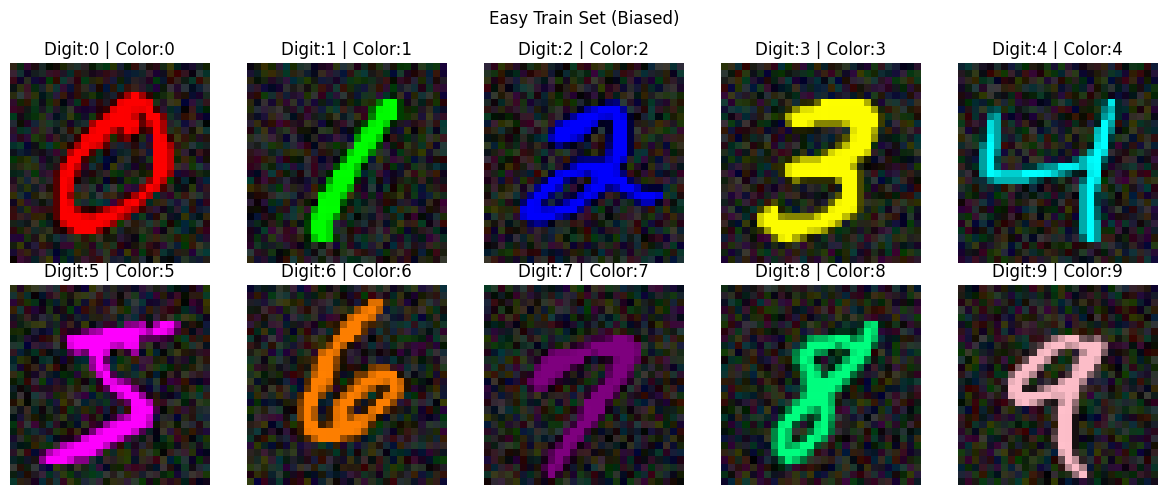

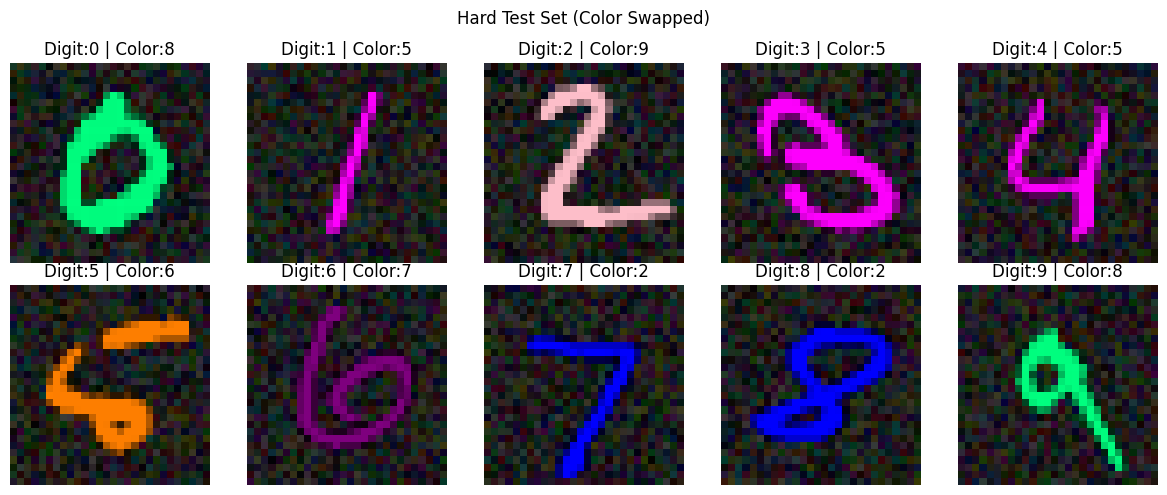

In [ ]:
# Visualize training set
visualize_digits(train_dataset, "Easy Train Set (Biased)")

# Visualize test set (will violate correlation)
visualize_digits(test_dataset, "Hard Test Set (Color Swapped)")

# **Task 1(Version 1)**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Dataset is being loaded for training purpose. Training for 85% and Validation is 15%.
# Split train into train/val
train_size = int(0.85 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_set, val_set = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
#Simple CNN was used for driving the experiments.
#Simple CNN was used because all the learned behaviours that it picked up was solely due to training on the modified MNIST.
#ResNet-18 has been trained on ImageNet and contain rich shape and texture and hence it was left out.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

Epoch 1: Train Acc = 0.9496, Val Acc = 0.9524
Epoch 2: Train Acc = 0.9508, Val Acc = 0.9536
Epoch 3: Train Acc = 0.9514, Val Acc = 0.9537
Epoch 4: Train Acc = 0.9513, Val Acc = 0.9540
Epoch 5: Train Acc = 0.9580, Val Acc = 0.9610


In [ ]:
#As expected the training and validation accuracy were of extremely high accuracy.
#Testing on Hard Test set reduced the accuracy below 20 percent.
hard_test_acc = evaluate(test_loader)
print(f"Hard Test Accuracy = {hard_test_acc:.4f}")

Hard Test Accuracy = 0.1803


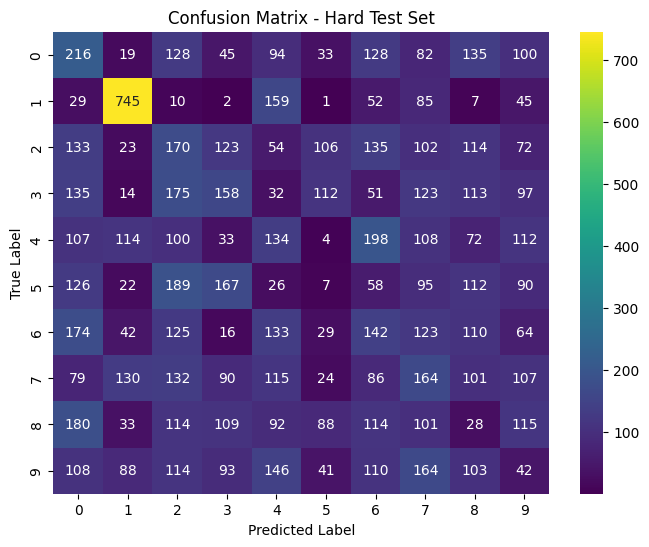

In [ ]:
def calculate_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm


cm = calculate_confusion_matrix(model, test_loader, device)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Hard Test Set")
plt.show()

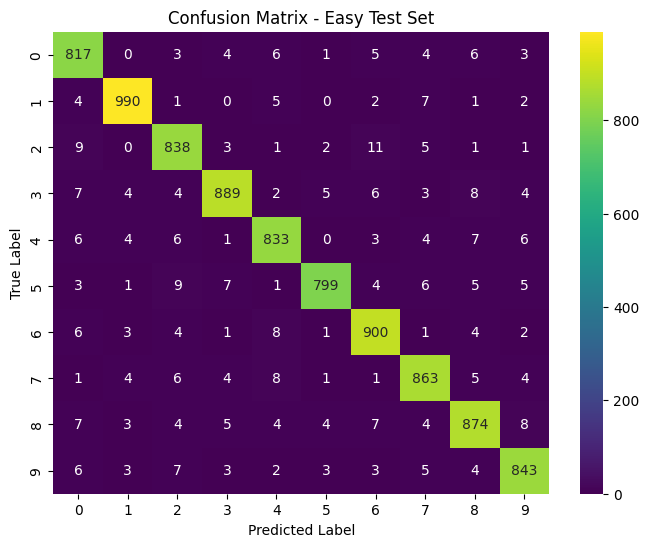

In [ ]:
def calculate_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm


cm = calculate_confusion_matrix(model, val_loader, device)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Easy Test Set")
plt.show()
# Reason for this confusion matrix: I just wanted to see!

In [ ]:
# To check shortcut learning, we are checking  whether is it color-dominant or not.
def test_conflicts(model, dataset, device, max_samples=10):
    model.eval()
    count = 0

    for idx in range(len(dataset)):
        label = dataset.mnist.targets[idx].item()
        color = dataset.color_assignments[idx]

        # Conflict case
        if label != color:
            img, _ = dataset[idx]
            img = img.unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(img).argmax(dim=1).item()

            print("---------")
            print(f"True Digit: {label}")
            print(f"Color Index: {color}")
            print(f"Model Prediction: {pred}")

            count += 1
            if count >= max_samples:
                break
test_conflicts(model, test_dataset, device)

---------
True Digit: 7
Color Index: 2
Model Prediction: 2
---------
True Digit: 2
Color Index: 9
Model Prediction: 2
---------
True Digit: 1
Color Index: 5
Model Prediction: 1
---------
True Digit: 0
Color Index: 8
Model Prediction: 8
---------
True Digit: 4
Color Index: 5
Model Prediction: 4
---------
True Digit: 1
Color Index: 7
Model Prediction: 1
---------
True Digit: 4
Color Index: 8
Model Prediction: 8
---------
True Digit: 9
Color Index: 8
Model Prediction: 8
---------
True Digit: 5
Color Index: 6
Model Prediction: 6
---------
True Digit: 9
Color Index: 1
Model Prediction: 4


In [ ]:
torch.save(model.state_dict(), "model_5epoch.pth")

# **Task 1 (Version 2)**

In [ ]:
# Version 2 simply check what would be the result if the model is ran for 10 epochs.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

Epoch 1: Train Acc = 0.9496, Val Acc = 0.9524
Epoch 2: Train Acc = 0.9507, Val Acc = 0.9534
Epoch 3: Train Acc = 0.9512, Val Acc = 0.9538
Epoch 4: Train Acc = 0.9538, Val Acc = 0.9560
Epoch 5: Train Acc = 0.9578, Val Acc = 0.9599
Epoch 6: Train Acc = 0.9622, Val Acc = 0.9630
Epoch 7: Train Acc = 0.9702, Val Acc = 0.9717
Epoch 8: Train Acc = 0.9722, Val Acc = 0.9741
Epoch 9: Train Acc = 0.9785, Val Acc = 0.9790
Epoch 10: Train Acc = 0.9789, Val Acc = 0.9791


In [ ]:
# Test and train accuracy goes up as expected. However, hard test accuracy goes up as well.
hard_test_acc = evaluate(test_loader)
print(f"Hard Test Accuracy = {hard_test_acc:.4f}")

Hard Test Accuracy = 0.6340


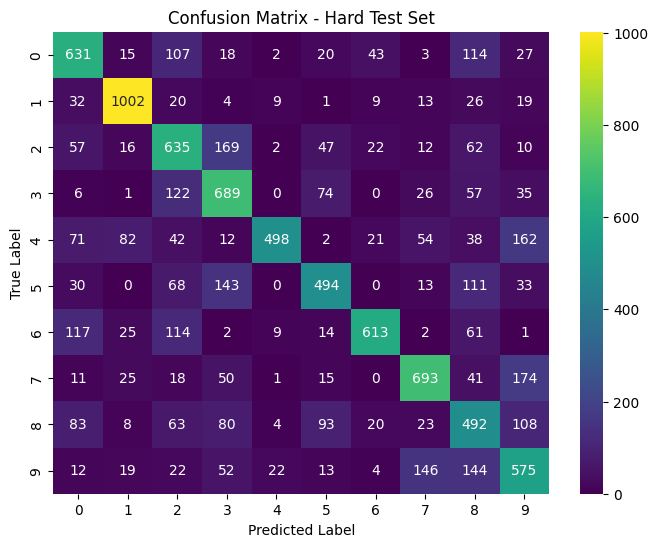

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def compute_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm


cm = compute_confusion_matrix(model, test_loader, device)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Hard Test Set")
plt.show()

In [ ]:
def test_conflicts(model, dataset, device, max_samples=10):
    model.eval()
    count = 0

    for idx in range(len(dataset)):
        label = dataset.mnist.targets[idx].item()
        color = dataset.color_assignments[idx]

        # Conflict case
        if label != color:
            img, _ = dataset[idx]
            img = img.unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(img).argmax(dim=1).item()

            print("---------")
            print(f"True Digit: {label}")
            print(f"Color Index: {color}")
            print(f"Model Prediction: {pred}")

            count += 1
            if count >= max_samples:
                break
test_conflicts(model, test_dataset, device)

---------
True Digit: 7
Color Index: 2
Model Prediction: 7
---------
True Digit: 2
Color Index: 9
Model Prediction: 2
---------
True Digit: 1
Color Index: 5
Model Prediction: 1
---------
True Digit: 0
Color Index: 8
Model Prediction: 8
---------
True Digit: 4
Color Index: 5
Model Prediction: 4
---------
True Digit: 1
Color Index: 7
Model Prediction: 1
---------
True Digit: 4
Color Index: 8
Model Prediction: 8
---------
True Digit: 9
Color Index: 8
Model Prediction: 8
---------
True Digit: 5
Color Index: 6
Model Prediction: 2
---------
True Digit: 9
Color Index: 1
Model Prediction: 9


In [ ]:
torch.save(model.state_dict(), "model_10epoch.pth")

# **Task 2 (Version 1)**
Early Layers


In [ ]:
model = SimpleCNN().to(device)
model.load_state_dict(torch.load("model_5epoch.pth"))
model.eval()

for param in model.parameters():
    param.requires_grad = False

In [ ]:
# Version 1 check what does neurons see in early convolutional filter in 5 Epoch model.
# According to result, it tries to check for colors and barely any other features.
def visualize_early_neuron(model, channel_idx, steps=300, lr=0.05):
    img = torch.randn(1, 3, 28, 28, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        activation = model.features[0](img)[0, channel_idx].mean()
        (-activation).backward()
        optimizer.step()
        img.data.clamp_(0, 1)

    img_np = img.detach().cpu().squeeze().permute(1, 2, 0).numpy()

    plt.imshow(img_np)
    plt.title(f"Early Layer Channel {channel_idx}")
    plt.axis("off")
    plt.show()

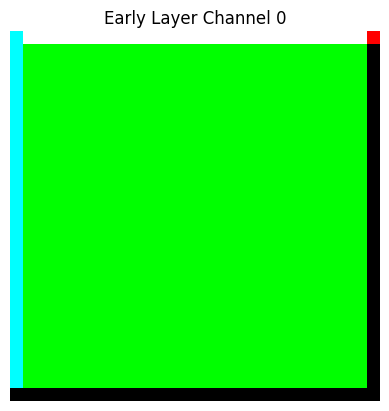

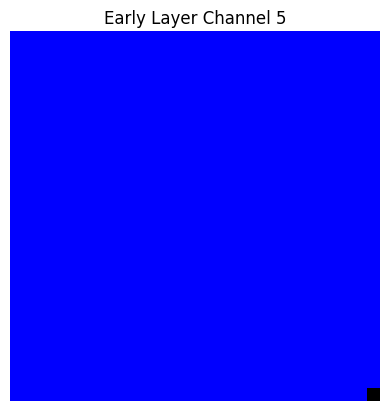

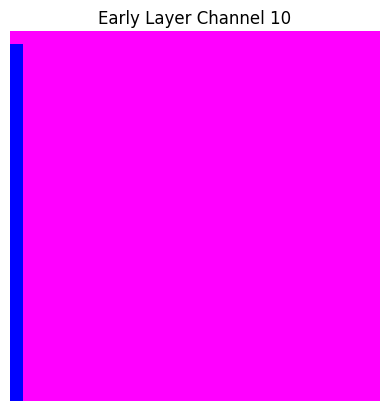

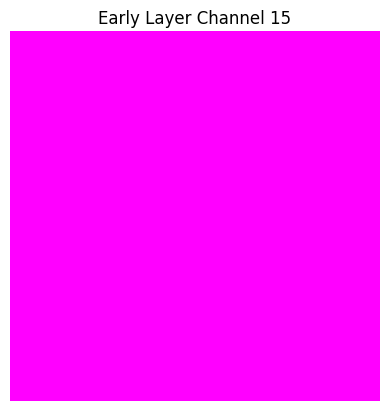

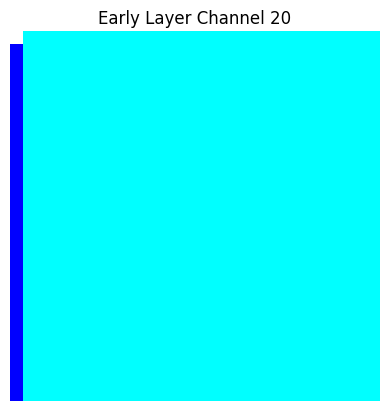

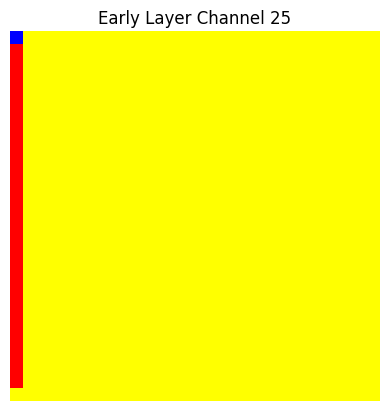

In [ ]:
for ch in [0, 5, 10, 15, 20, 25]:
    visualize_early_neuron(model, ch)

**Deeper Layers**

In [ ]:
# Here deeper layers are being probed to see what deeper convolutional filters are trying to check.
# It is trying to check the shapes here.
def visualize_deep_neuron(model, channel_idx, steps=400, lr=0.05):
    img = torch.randn(1, 3, 28, 28, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        activation = model.features[:7](img)[0, channel_idx].mean()
        (-activation).backward()
        optimizer.step()
        img.data.clamp_(0, 1)

    img_np = img.detach().cpu().squeeze().permute(1, 2, 0).numpy()

    plt.imshow(img_np)
    plt.title(f"Deep Layer Channel {channel_idx}")
    plt.axis("off")
    plt.show()


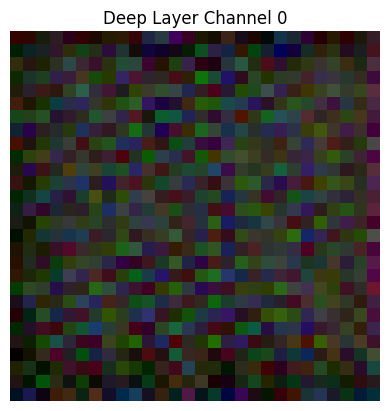

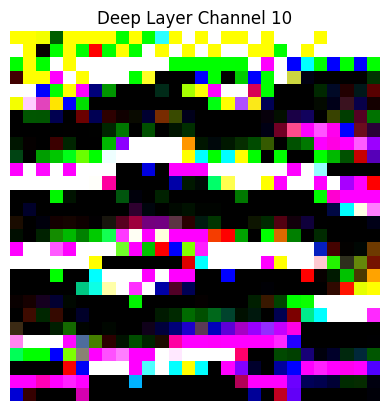

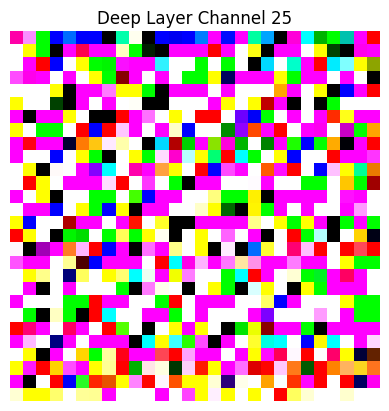

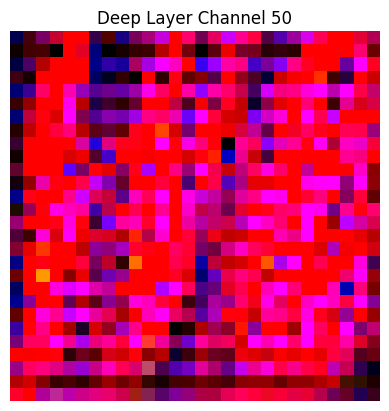

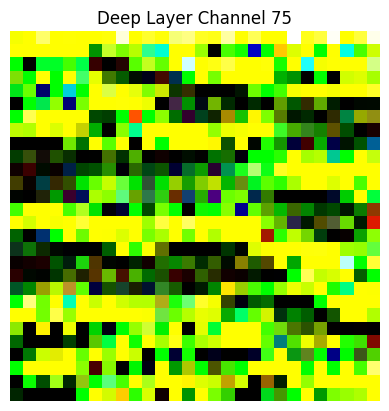

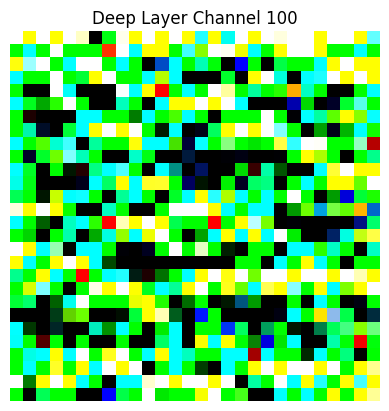

In [ ]:
for ch in [0, 10, 25, 50, 75, 100]:
    visualize_deep_neuron(model, ch)

# **Task 2(Version 2)**
Earlier Layers


In [ ]:
model = SimpleCNN().to(device)
model.load_state_dict(torch.load("model_10epoch.pth"))
model.eval()

for param in model.parameters():
    param.requires_grad = False

In [ ]:
# Version 2 executes the same thing but on 10 epoch model.
# There are some visual differences between them.
def visualize_early_neuron(model, channel_idx, steps=400, lr=0.05):
    img = torch.randn(1, 3, 28, 28, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        activation = model.features[0](img)[0, channel_idx].mean()
        (-activation).backward()
        optimizer.step()
        img.data.clamp_(0, 1)

    img_np = img.detach().cpu().squeeze().permute(1, 2, 0).numpy()

    plt.imshow(img_np)
    plt.title(f"Early Layer Channel {channel_idx}")
    plt.axis("off")
    plt.show()


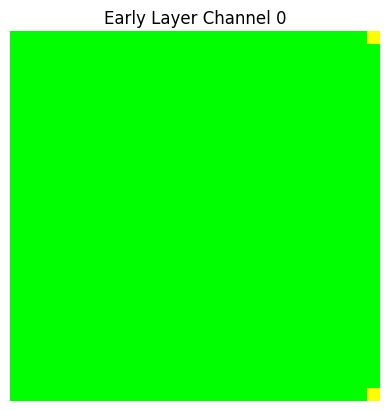

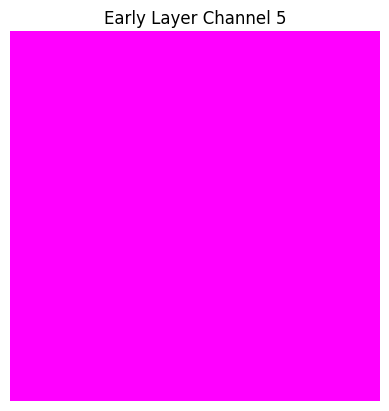

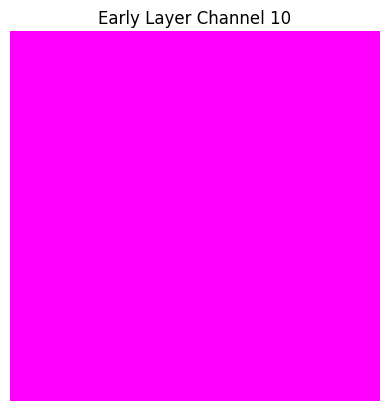

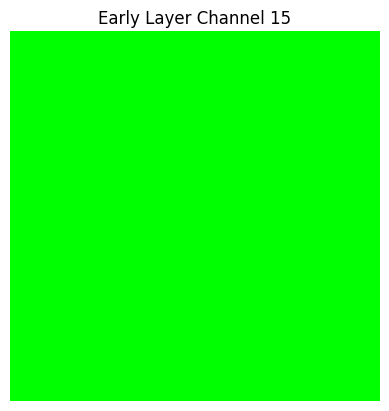

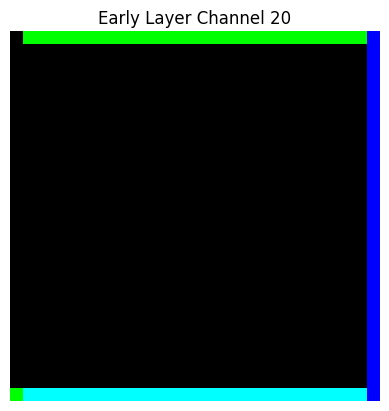

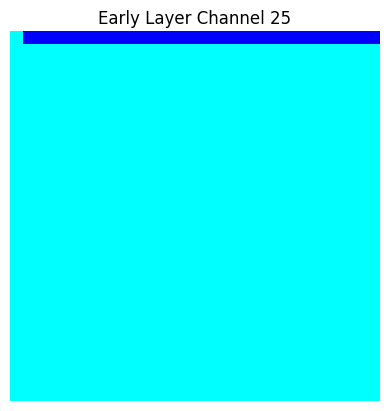

In [ ]:
for ch in [0, 5, 10, 15, 20, 25]:
    visualize_early_neuron(model, ch)

**Deeper Layers**

In [ ]:
def visualize_deep_neuron(model, channel_idx, steps=400, lr=0.05):
    img = torch.randn(1, 3, 28, 28, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        activation = model.features[:7](img)[0, channel_idx].mean()
        (-activation).backward()
        optimizer.step()
        img.data.clamp_(0, 1)

    img_np = img.detach().cpu().squeeze().permute(1, 2, 0).numpy()

    plt.imshow(img_np)
    plt.title(f"Deep Layer Channel {channel_idx}")
    plt.axis("off")
    plt.show()


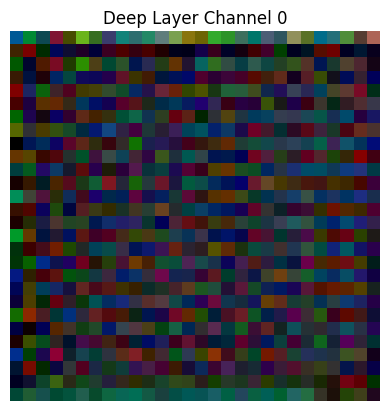

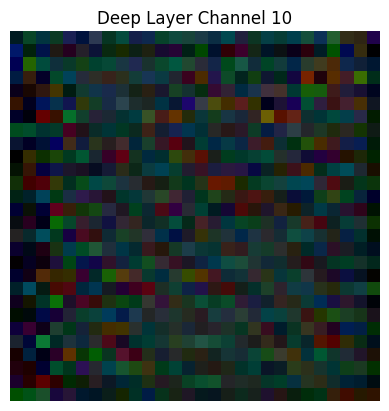

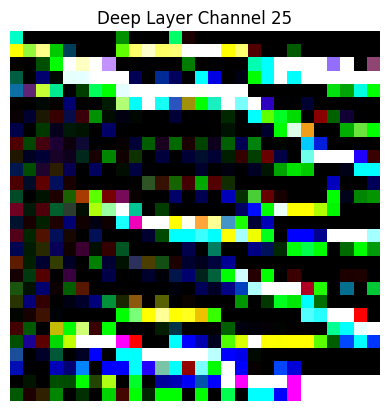

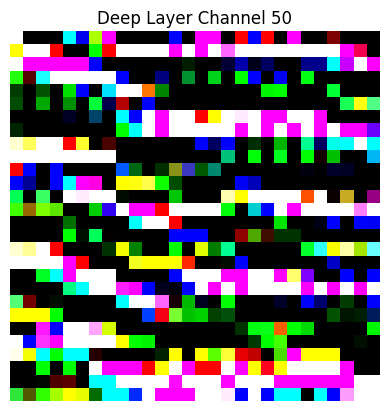

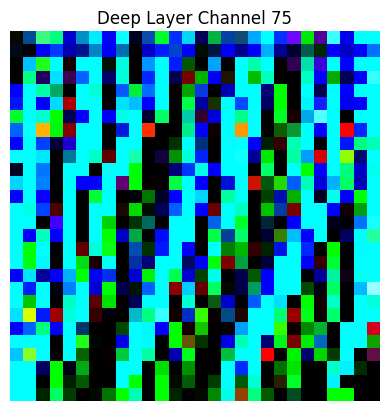

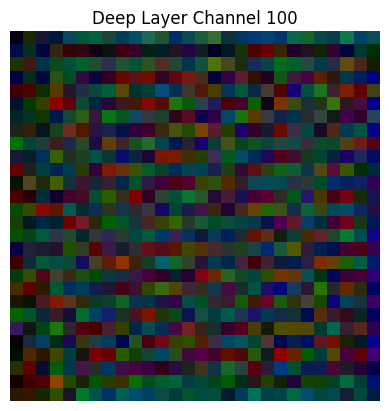

In [ ]:
for ch in [0, 10, 25, 50, 75, 100]:
    visualize_deep_neuron(model, ch)

# **Task 3 (Version 1)**

In [ ]:
#Task 3 Evaluation for 5 epoch model
model5 = SimpleCNN().to(device)
model5.load_state_dict(torch.load("model_5epoch.pth"))
model5.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
# GRAD-CAM is implemented here from scratch to visualise the spatial regions of image which influence the model's prediction
# It highlights the areas in the image which contributes mostly to a specific class prediction.
feature_maps = None
gradients = None

def forward_hook(module, input, output):
    global feature_maps
    feature_maps = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

# Register hooks on last conv layer
target_layer = model5.features[6]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_backward_hook(backward_hook)

In [ ]:
import torch.nn.functional as F

def generate_gradcam(model, input_tensor, class_idx=None):
    global feature_maps, gradients

    model.zero_grad()

    output = model(input_tensor)

    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    score = output[0, class_idx]
    score.backward()

    # Compute channel-wise weights
    weights = gradients.mean(dim=(2, 3), keepdim=True)

    # Weighted sum of feature maps
    cam = (weights * feature_maps).sum(dim=1, keepdim=True)

    cam = F.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()

   # Normalize between 0 and 1
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return cam

In [ ]:
def visualize_gradcam(model, dataset, idx):
    img, label = dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    cam = generate_gradcam(model, input_tensor)

    img_np = img.permute(1, 2, 0).numpy()

    # Resize CAM to 28x28
    cam_resized = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_resized = F.interpolate(cam_resized, size=(28, 28), mode='bilinear', align_corners=False)
    cam_resized = cam_resized.squeeze().numpy()

    plt.figure(figsize=(4,4))
    plt.imshow(img_np)
    plt.imshow(cam_resized, cmap='jet', alpha=0.5)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


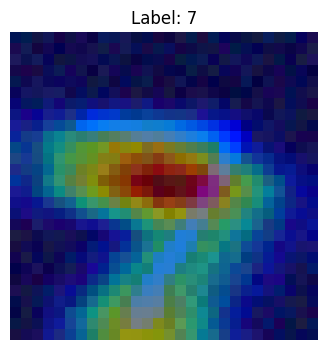

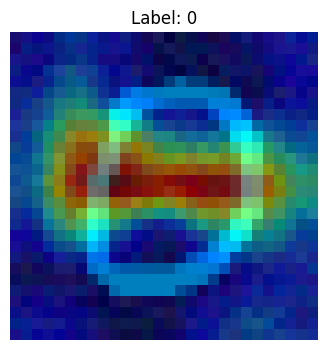

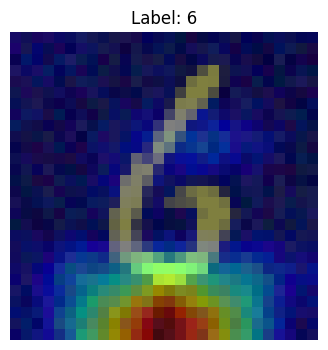

In [ ]:
visualize_gradcam(model5, test_dataset, 0)
visualize_gradcam(model5, test_dataset, 10)
visualize_gradcam(model5, test_dataset, 50)
# We can see here that which point of the image has been highlighted using Grad-Cam function.

# **Task 3 (Version 2)**

In [ ]:
model_10 = SimpleCNN().to(device)
model_10.load_state_dict(torch.load("model_10epoch.pth"))
model_10.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
# Version 2 does the same as Version 1, but on 10 epoch mode.
import torch.nn.functional as F


def generate_gradcam(model, input_tensor, class_idx=None):
    global feature_maps, gradients

    model.zero_grad()

    output = model(input_tensor)

    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    score = output[0, class_idx]
    score.backward()

    # Compute channel-wise weights
    weights = gradients.mean(dim=(2, 3), keepdim=True)

    # Weighted sum of feature maps
    cam = (weights * feature_maps).sum(dim=1, keepdim=True)

    cam = F.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()

    # Normalize between 0 and 1
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    return cam

In [ ]:
def visualize_gradcam(model, dataset, idx):
    img, label = dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    cam = generate_gradcam(model, input_tensor)

    img_np = img.permute(1, 2, 0).numpy()

    # Resize CAM to 28x28
    cam_resized = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_resized = F.interpolate(cam_resized, size=(28, 28), mode='bilinear', align_corners=False)
    cam_resized = cam_resized.squeeze().numpy()

    plt.figure(figsize=(4,4))
    plt.imshow(img_np)
    plt.imshow(cam_resized, cmap='jet', alpha=0.5)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

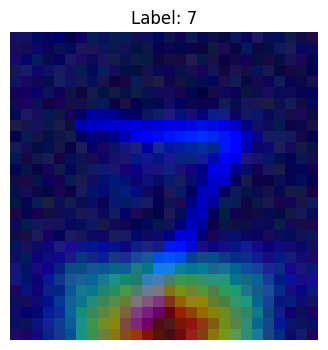

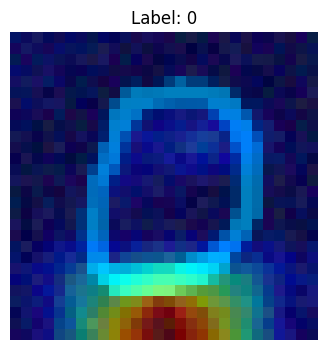

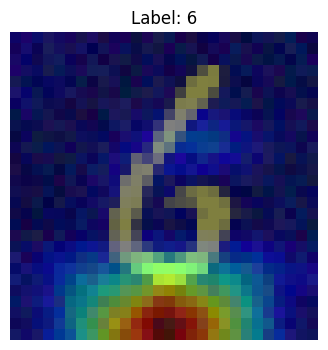

In [ ]:
visualize_gradcam(model_10, test_dataset, 0)
visualize_gradcam(model_10, test_dataset, 10)
visualize_gradcam(model_10, test_dataset, 50)

# **Task 3 (AHA Moment)**

In [ ]:

model5 = SimpleCNN().to(device)
model5.load_state_dict(torch.load("model_5epoch.pth", map_location=device))
model5.eval()

model10 = SimpleCNN().to(device)
model10.load_state_dict(torch.load("model_10epoch.pth", map_location=device))
model10.eval()

print("Models loaded.")

Models loaded.


In [ ]:
# Aha Moment:
# Grad-CAM reveals that the model does not consistently focus on digits shapes or edges.
# In biased samples, activation spreads across colored regions.
# In conflict samples, the early-trained model shifts attention toward color leading to incorrect predictions.
# This demonstrates shortcut learning: the model exploits color-label correlation
# instead of relying purely on digit shape.
feature_maps = None
gradients = None

def forward_hook(module, inp, out):
    global feature_maps
    feature_maps = out

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

In [ ]:
model5.features[6].register_forward_hook(forward_hook)
model5.features[6].register_full_backward_hook(backward_hook)

model10.features[6].register_forward_hook(forward_hook)
model10.features[6].register_full_backward_hook(backward_hook)

In [ ]:
def generate_gradcam(model, x):
    global feature_maps, gradients

    model.zero_grad()
    out = model(x)
    class_idx = out.argmax(dim=1).item()
    out[0, class_idx].backward()

    weights = gradients.mean(dim=(2,3), keepdim=True)
    cam = (weights * feature_maps).sum(dim=1).relu()

    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    return cam

In [ ]:
def find_biased_example(dataset):
    for idx in range(len(dataset)):
        label = dataset.mnist.targets[idx].item()
        color = dataset.color_assignments[idx]

        if label == color:
            return idx, label, color

    return None, None, None


biased_idx, biased_label, biased_color = find_biased_example(train_dataset)

print("Biased Example")
print("Index:", biased_idx)
print("Label:", biased_label)
print("Color:", biased_color)

Biased Example
Index: 0
Label: 5
Color: 5


In [ ]:
def find_conflict_example(dataset):
    for idx in range(len(dataset)):
        label = dataset.mnist.targets[idx].item()
        color = dataset.color_assignments[idx]

        if label != color:
            return idx, label, color

    return None, None, None


conflict_idx, conflict_label, conflict_color = find_conflict_example(test_dataset)

print("Conflict Example")
print("Index:", conflict_idx)
print("Label:", conflict_label)
print("Color:", conflict_color)

Conflict Example
Index: 0
Label: 7
Color: 2


In [ ]:
def compare_models_on_sample(idx, dataset, title):
    img, label = dataset[idx]
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred5 = model5(x).argmax(dim=1).item()
        pred10 = model10(x).argmax(dim=1).item()

    cam5 = generate_gradcam(model5, x)
    cam10 = generate_gradcam(model10, x)

    cam5 = torch.tensor(cam5)[None,None]
    cam10 = torch.tensor(cam10)[None,None]

    cam5 = F.interpolate(cam5, size=(28,28), mode='bilinear').squeeze().numpy()
    cam10 = F.interpolate(cam10, size=(28,28), mode='bilinear').squeeze().numpy()

    img_np = img.permute(1,2,0).numpy()

    plt.figure(figsize=(10,4))
    plt.suptitle(title)

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.imshow(cam5, cmap='jet', alpha=0.5)
    plt.title(f"5 Epoch (Pred: {pred5})")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img_np)
    plt.imshow(cam10, cmap='jet', alpha=0.5)
    plt.title(f"10 Epoch (Pred: {pred10})")
    plt.axis("off")

    plt.show()

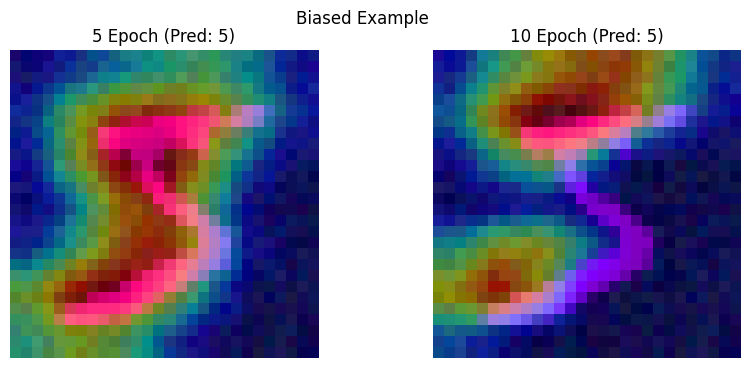

In [ ]:
compare_models_on_sample(biased_idx, train_dataset, "Biased Example")

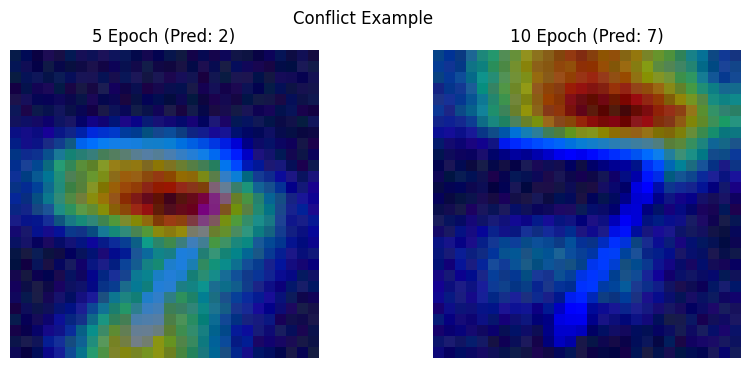

In [ ]:
compare_models_on_sample(conflict_idx, test_dataset, "Conflict Example")

# **Task 4**
Trial 1

In [ ]:
import torch # These libraries have been imported again because it looks good!
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Sobel filter has been used as image preprocessing which extracts edge(gradient) information from the image
# Model was encouraged to rely more on structural shape than pure color as it has been instructed
kernel_x = torch.tensor([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=torch.float32, device=device).view(1,1,3,3)

kernel_y = torch.tensor([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]], dtype=torch.float32, device=device).view(1,1,3,3)

def sobel_edges(x):
    edges = []
    for c in range(3):
        ch = x[:, c:c+1]
        gx = F.conv2d(ch, kernel_x, padding=1)
        gy = F.conv2d(ch, kernel_y, padding=1)
        grad = torch.sqrt(gx**2 + gy**2 + 1e-6)
        edges.append(grad)
    return torch.cat(edges, dim=1)



# Model Setup

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

lambda_consistency = 0.3
EPOCHS = 10

# Training Loop


for epoch in range(EPOCHS):

    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Original forward pass
        outputs = model(images)
        loss_ce = criterion(outputs, labels)

        # Sobel edge forward pass
        edge_images = sobel_edges(images)
        outputs_edges = model(edge_images)

        # Consistency loss
        p = F.softmax(outputs, dim=1)
        p_edges = F.softmax(outputs_edges, dim=1)
        loss_cons = F.mse_loss(p, p_edges)

        loss = loss_ce + lambda_consistency * loss_cons
        loss.backward()
        optimizer.step()

        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

hard_acc = evaluate(test_loader)
print("Hard Test Accuracy:", hard_acc) # It didn't reach the desire result but was worth the experiment.

Epoch 1: Train Acc = 0.9052, Val Acc = 0.9513
Epoch 2: Train Acc = 0.9495, Val Acc = 0.9526
Epoch 3: Train Acc = 0.9502, Val Acc = 0.9534
Epoch 4: Train Acc = 0.9508, Val Acc = 0.9534
Epoch 5: Train Acc = 0.9525, Val Acc = 0.9556
Epoch 6: Train Acc = 0.9566, Val Acc = 0.9603
Epoch 7: Train Acc = 0.9626, Val Acc = 0.9694
Epoch 8: Train Acc = 0.9690, Val Acc = 0.9738
Epoch 9: Train Acc = 0.9744, Val Acc = 0.9790
Epoch 10: Train Acc = 0.9776, Val Acc = 0.9794
Hard Test Accuracy: 0.6029


**Trial Version 2**

In [ ]:
import random
from torchvision import transforms

# Introduced stochastic (random) color trnsformation. Color variance was increased.
# Encouraged the model to learn color-invariant features.
# channel Dropout was to act as regulariser.
# Discouraged dependence on single color channel.

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Strong color jitter
color_jitter = transforms.ColorJitter(
    brightness=0.6,
    contrast=0.6,
    saturation=0.6,
    hue=0.3
)

drop_prob = 0.3
EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)


        # Channel Dropout

        if random.random() < drop_prob:
            channel_to_drop = random.randint(0, 2)
            x[:, channel_to_drop, :, :] = 0.0


        #Color Jitter

        jittered = []
        for img in x:
            jittered.append(color_jitter(img.cpu()))
        x = torch.stack(jittered).to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

hard_acc = evaluate(test_loader)
print("Hard Test Accuracy:", hard_acc)

Epoch 1: Train Acc = 0.7308, Val Acc = 0.7302
Epoch 2: Train Acc = 0.8567, Val Acc = 0.8567
Epoch 3: Train Acc = 0.9153, Val Acc = 0.9136
Epoch 4: Train Acc = 0.9368, Val Acc = 0.9352
Epoch 5: Train Acc = 0.9555, Val Acc = 0.9533
Hard Test Accuracy: 0.7867


In [ ]:
torch.save(model.state_dict(), "model5_trial_version2.pth") # It was a success!

In [ ]:
import random
from torchvision import transforms

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Strong color jitter
color_jitter = transforms.ColorJitter(
    brightness=0.6,
    contrast=0.6,
    saturation=0.6,
    hue=0.3
)

drop_prob = 0.3
EPOCHS = 10

for epoch in range(EPOCHS):

    model.train()

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)


        # Channel Dropout

        if random.random() < drop_prob:
            channel_to_drop = random.randint(0, 2)
            x[:, channel_to_drop, :, :] = 0.0


        # Color Jitter

        jittered = []
        for img in x:
            jittered.append(color_jitter(img.cpu()))
        x = torch.stack(jittered).to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

hard_acc = evaluate(test_loader)
print("Hard Test Accuracy:", hard_acc)

Epoch 1: Train Acc = 0.7935, Val Acc = 0.7899
Epoch 2: Train Acc = 0.9083, Val Acc = 0.9029
Epoch 3: Train Acc = 0.9320, Val Acc = 0.9303
Epoch 4: Train Acc = 0.9225, Val Acc = 0.9194
Epoch 5: Train Acc = 0.9481, Val Acc = 0.9479
Epoch 6: Train Acc = 0.9483, Val Acc = 0.9439
Epoch 7: Train Acc = 0.9627, Val Acc = 0.9631
Epoch 8: Train Acc = 0.9688, Val Acc = 0.9689
Epoch 9: Train Acc = 0.9687, Val Acc = 0.9699
Epoch 10: Train Acc = 0.9716, Val Acc = 0.9702
Hard Test Accuracy: 0.8796


In [ ]:
torch.save(model.state_dict(), "model10_trial_version2.pth")

**Trial Version 3**



In [ ]:
import random
from torchvision import transforms
import torch.nn.functional as F

# This version explicitly penalize prediction changes under color perturbation and encourage shape-based learning.

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Color perturbation (only for penalty branch)
color_shift = transforms.ColorJitter(
    brightness=0.5,
    contrast=0.5,
    saturation=0.7,
    hue=0.3
)

lambda_color = 0.7
EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    for x, y in train_loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        # Original prediction
        out = model(x)
        loss_ce = criterion(out, y)

        # Color-perturbed version
        shifted = []
        for img in x:
            shifted.append(color_shift(img.cpu()))
        x_color = torch.stack(shifted).to(device)

        out_color = model(x_color)

        # Color invariance penalty
        p = F.softmax(out, dim=1)
        p_color = F.softmax(out_color, dim=1)

        loss_color = F.mse_loss(p, p_color)

        loss = loss_ce + lambda_color * loss_color
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

hard_acc = evaluate(test_loader)
print("Hard Test Accuracy:", hard_acc) # Result slumps hard

Epoch 1: Train Acc = 0.9500, Val Acc = 0.9526
Epoch 2: Train Acc = 0.9505, Val Acc = 0.9538
Epoch 3: Train Acc = 0.9530, Val Acc = 0.9552
Epoch 4: Train Acc = 0.9560, Val Acc = 0.9584
Epoch 5: Train Acc = 0.9625, Val Acc = 0.9653
Hard Test Accuracy: 0.2858


In [ ]:
# Save model weights
torch.save(model.state_dict(), "task4_color5_penalty.pth")



In [ ]:
import random
from torchvision import transforms
import torch.nn.functional as F

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Color perturbation (only for penalty branch)
color_shift = transforms.ColorJitter(
    brightness=0.5,
    contrast=0.5,
    saturation=0.7,
    hue=0.3
)

lambda_color = 0.7
EPOCHS = 10

for epoch in range(EPOCHS):

    model.train()

    for x, y in train_loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        # Original prediction
        out = model(x)
        loss_ce = criterion(out, y)

        # Color-perturbed version
        shifted = []
        for img in x:
            shifted.append(color_shift(img.cpu()))
        x_color = torch.stack(shifted).to(device)

        out_color = model(x_color)

        # Color invariance penalty
        p = F.softmax(out, dim=1)
        p_color = F.softmax(out_color, dim=1)

        loss_color = F.mse_loss(p, p_color)

        loss = loss_ce + lambda_color * loss_color
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

hard_acc = evaluate(test_loader)
print("Hard Test Accuracy:", hard_acc) # Result is surprisingly good for 10 epochs.

Epoch 1: Train Acc = 0.9481, Val Acc = 0.9509
Epoch 2: Train Acc = 0.9504, Val Acc = 0.9530
Epoch 3: Train Acc = 0.9505, Val Acc = 0.9526
Epoch 4: Train Acc = 0.9527, Val Acc = 0.9544
Epoch 5: Train Acc = 0.9592, Val Acc = 0.9612
Epoch 6: Train Acc = 0.9710, Val Acc = 0.9711
Epoch 7: Train Acc = 0.9738, Val Acc = 0.9736
Epoch 8: Train Acc = 0.9775, Val Acc = 0.9786
Epoch 9: Train Acc = 0.9823, Val Acc = 0.9819
Epoch 10: Train Acc = 0.9807, Val Acc = 0.9826
Hard Test Accuracy: 0.7394


In [ ]:
# Save model weights
torch.save(model.state_dict(), "task4_color10_penalty.pth")



# **Task 5 (Version 1)**


In [ ]:
model_lazy = SimpleCNN().to(device)
model_lazy.load_state_dict(torch.load("/content/model_5epoch.pth", map_location=device))
model_lazy.eval()

for p in model_lazy.parameters():
    p.requires_grad = False

model_robust = SimpleCNN().to(device)
model_robust.load_state_dict(torch.load("/content/model5_trial_version2.pth", map_location=device))
model_robust.eval()

for p in model_robust.parameters():
    p.requires_grad = False

In [ ]:
# Targeted PGD attack is defined
def targeted_pgd(model, image, target_class=3,
                 epsilon=0.05, alpha=0.005, steps=40):
    #Adversarial image is initialised from the original image
    adv = image.clone().detach().to(device)
    adv.requires_grad = True

    original = image.clone().detach()
#iterative attack process is performed
    for step in range(steps):

        output = model(adv)
        loss = F.cross_entropy(output, torch.tensor([target_class]).to(device))

        model.zero_grad()
        loss.backward()
        # Adversarial image is updated using gradient sign (targeted direction)
        adv = adv - alpha * adv.grad.sign()

        # Perturbation is projected back into the epsilon constraint region
        perturbation = torch.clamp(adv - original, -epsilon, epsilon)
        adv = torch.clamp(original + perturbation, 0, 1).detach()
        adv.requires_grad = True

        probs = F.softmax(model(adv), dim=1)
        confidence = probs[0, target_class].item()
        # Attack success condition is checked
        if confidence > 0.90:
            print(f"Attack succeeded at step {step}")
            break

    return adv, step, confidence

In [ ]:
for idx in range(len(test_dataset)):
    img, label = test_dataset[idx]
    if label == 7: # Condition is checked to find a digit '7'
        original_img = img.unsqueeze(0).to(device)
        print("Using index:", idx)
        break

Using index: 0


In [ ]:
adv_lazy, steps_lazy, conf_lazy = targeted_pgd(model_lazy, original_img, target_class=3)
print("Lazy model confidence:", conf_lazy)

adv_robust, steps_robust, conf_robust = targeted_pgd(model_robust, original_img, target_class=3)
print("Robust model confidence:", conf_robust)

Lazy model confidence: 0.2117309868335724
Attack succeeded at step 9
Robust model confidence: 0.9497350454330444


In [ ]:
def compute_linf(original, adv):
    return torch.max(torch.abs(adv - original)).item()

linf_lazy = compute_linf(original_img, adv_lazy)
linf_robust = compute_linf(original_img, adv_robust)

print("Lazy L_inf:", linf_lazy)
print("Robust L_inf:", linf_robust)

Lazy L_inf: 0.050000011920928955
Robust L_inf: 0.05000000447034836


In [ ]:
def show_attack(original, adv):

    diff = adv - original

    original = original.squeeze().permute(1,2,0).cpu().detach().numpy()
    adv = adv.squeeze().permute(1,2,0).cpu().detach().numpy()
    diff = diff.squeeze().permute(1,2,0).cpu().detach().numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Adversarial")
    plt.imshow(adv)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Difference")
    plt.imshow(diff)
    plt.axis("off")

    plt.show()

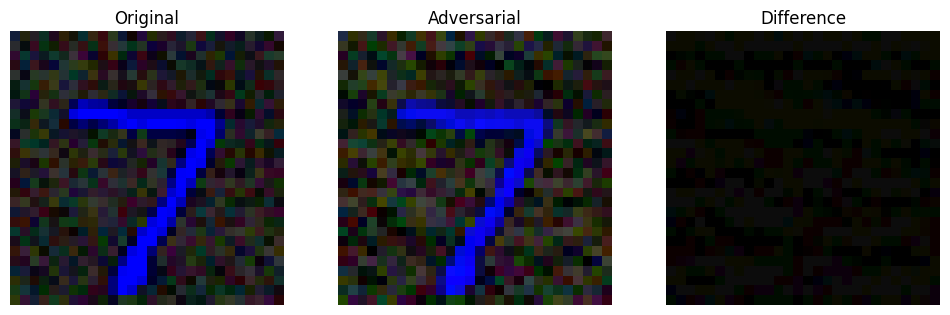

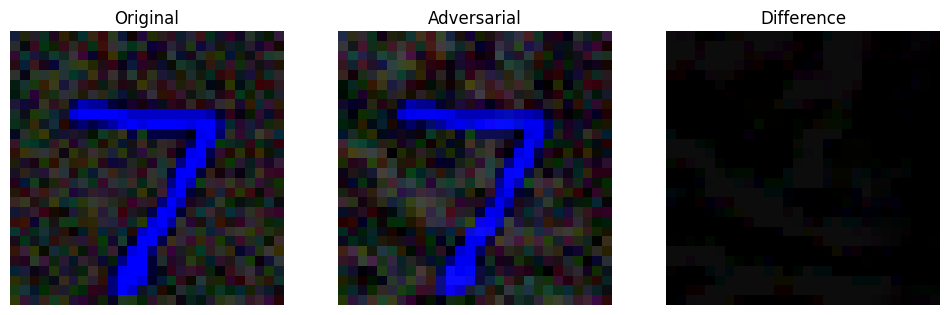

In [ ]:
show_attack(original_img, adv_lazy)
show_attack(original_img, adv_robust)

In [ ]:
seven_indices = []

for idx in range(len(test_dataset)):
    _, label = test_dataset[idx]
    if label == 7:
        seven_indices.append(idx)
    if len(seven_indices) == 10:
        break

print("Selected indices:", seven_indices)

Selected indices: [0, 17, 26, 34, 36, 41, 60, 64, 70, 75]


In [ ]:
results = []

for idx in seven_indices:

    img, _ = test_dataset[idx]
    original_img = img.unsqueeze(0).to(device)

    # -------- Lazy Model Attack --------
    adv_lazy, steps_lazy, conf_lazy = targeted_pgd(
        model_lazy, original_img, target_class=3
    )

    linf_lazy = compute_linf(original_img, adv_lazy)

    if steps_lazy == 40:
        print("Lazy model → attack FAILED (max steps reached)")
    else:
        print(f"Lazy model → attack succeeded at step {steps_lazy}")

    print(f"Lazy model L_inf perturbation: {linf_lazy:.4f}")


    # -------- Robust Model Attack --------
    adv_robust, steps_robust, conf_robust = targeted_pgd(
        model_robust, original_img, target_class=3
    )

    linf_robust = compute_linf(original_img, adv_robust)

    if steps_robust == 40:
        print("Robust model → attack FAILED (max steps reached)")
    else:
        print(f"Robust model → attack succeeded at step {steps_robust}")

    print(f"Robust model L_inf perturbation: {linf_robust:.4f}")


    # -------- Store Results --------
    results.append({
        "steps_lazy": steps_lazy,
        "steps_robust": steps_robust,
        "linf_lazy": linf_lazy,
        "linf_robust": linf_robust
    })

    print(f"Finished index {idx}")

Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Attack succeeded at step 9
Robust model → attack succeeded at step 9
Robust model L_inf perturbation: 0.0500
Finished index 0
Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Robust model → attack succeeded at step 39
Robust model L_inf perturbation: 0.0500
Finished index 17
Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Attack succeeded at step 5
Robust model → attack succeeded at step 5
Robust model L_inf perturbation: 0.0300
Finished index 26
Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Attack succeeded at step 9
Robust model → attack succeeded at step 9
Robust model L_inf perturbation: 0.0500
Finished index 34
Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Attack succeeded at step 7
Robust model → attack succeeded at step 7
Robust model L_inf perturbation: 0.0400
Finished index 

In [ ]:
steps_lazy_avg = np.mean([r["steps_lazy"] for r in results])
steps_robust_avg = np.mean([r["steps_robust"] for r in results])

linf_lazy_avg = np.mean([r["linf_lazy"] for r in results])
linf_robust_avg = np.mean([r["linf_robust"] for r in results])

print("AVERAGE RESULTS ")
print("Avg steps (lazy):", steps_lazy_avg)
print("Avg steps (robust):", steps_robust_avg)
print("Avg L_inf (lazy):", linf_lazy_avg)
print("Avg L_inf (robust):", linf_robust_avg)

AVERAGE RESULTS 
Avg steps (lazy): 39.0
Avg steps (robust): 12.8
Avg L_inf (lazy): 0.050000011920928955
Avg L_inf (robust): 0.03900001123547554


# **Task 5 (Version 2)**

In [ ]:
model_lazy = SimpleCNN().to(device)
model_lazy.load_state_dict(torch.load("/content/model_10epoch.pth", map_location=device))
model_lazy.eval()

for p in model_lazy.parameters():
    p.requires_grad = False

model_robust = SimpleCNN().to(device)
model_robust.load_state_dict(torch.load("/content/model10_trial_version2.pth", map_location=device))
model_robust.eval()

for p in model_robust.parameters():
    p.requires_grad = False

In [ ]:

def targeted_pgd(model, image, target_class=3,
                 epsilon=0.05, alpha=0.005, steps=40):

    adv = image.clone().detach().to(device)
    adv.requires_grad = True

    original = image.clone().detach()

    for step in range(steps):

        output = model(adv)
        loss = F.cross_entropy(output, torch.tensor([target_class]).to(device))

        model.zero_grad()
        loss.backward()

        adv = adv - alpha * adv.grad.sign()


        perturbation = torch.clamp(adv - original, -epsilon, epsilon)
        adv = torch.clamp(original + perturbation, 0, 1).detach()
        adv.requires_grad = True

        probs = F.softmax(model(adv), dim=1)
        confidence = probs[0, target_class].item()

        if confidence > 0.90:
            print(f"Attack succeeded at step {step}")
            break

    return adv, step, confidence

In [ ]:
for idx in range(len(test_dataset)):
    img, label = test_dataset[idx]
    if label == 7:
        original_img = img.unsqueeze(0).to(device)
        print("Using index:", idx)
        break

Using index: 0


In [ ]:
adv_lazy, steps_lazy, conf_lazy = targeted_pgd(model_lazy, original_img, target_class=3)
print("Lazy model confidence:", conf_lazy)

adv_robust, steps_robust, conf_robust = targeted_pgd(model_robust, original_img, target_class=3)
print("Robust model confidence:", conf_robust)

Lazy model confidence: 0.6858617663383484
Robust model confidence: 0.3893173635005951


In [ ]:
def compute_linf(original, adv):
    return torch.max(torch.abs(adv - original)).item()

linf_lazy = compute_linf(original_img, adv_lazy)
linf_robust = compute_linf(original_img, adv_robust)

print("Lazy L_inf:", linf_lazy)
print("Robust L_inf:", linf_robust)

Lazy L_inf: 0.050000011920928955
Robust L_inf: 0.050000011920928955


In [ ]:
def show_attack(original, adv):

    diff = adv - original

    original = original.squeeze().permute(1,2,0).cpu().detach().numpy()
    adv = adv.squeeze().permute(1,2,0).cpu().detach().numpy()
    diff = diff.squeeze().permute(1,2,0).cpu().detach().numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Adversarial")
    plt.imshow(adv)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Difference")
    plt.imshow(diff)
    plt.axis("off")

    plt.show()

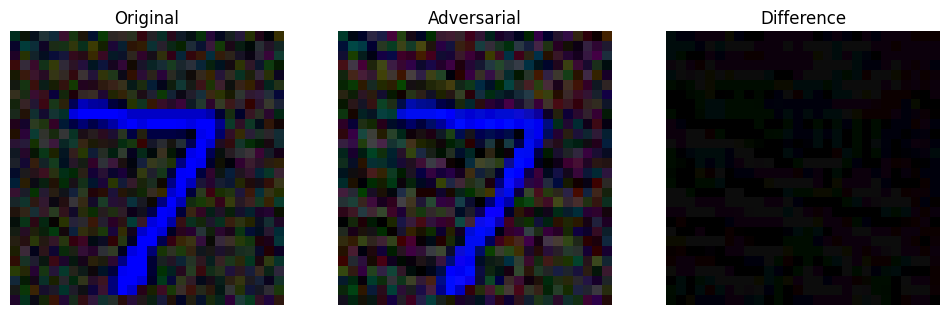

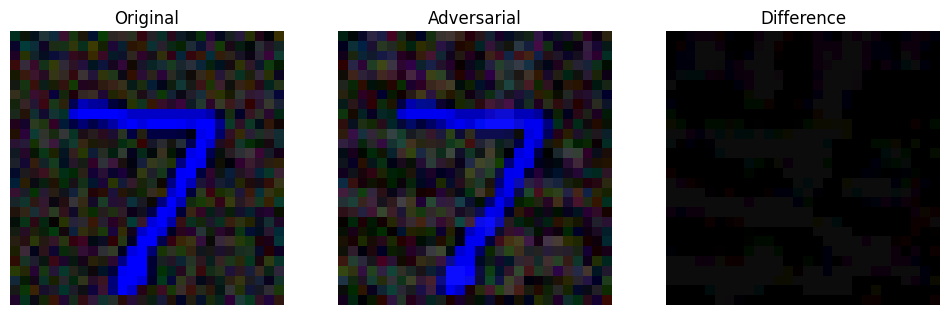

In [ ]:
show_attack(original_img, adv_lazy)
show_attack(original_img, adv_robust)

In [ ]:
seven_indices = []

for idx in range(len(test_dataset)):
    _, label = test_dataset[idx]
    if label == 7:
        seven_indices.append(idx)
    if len(seven_indices) == 10:
        break

print("Selected indices:", seven_indices)

Selected indices: [0, 17, 26, 34, 36, 41, 60, 64, 70, 75]


In [ ]:
results = []

for idx in seven_indices:

    img, _ = test_dataset[idx]
    original_img = img.unsqueeze(0).to(device)

    # -------- Lazy Model Attack --------
    adv_lazy, steps_lazy, conf_lazy = targeted_pgd(
        model_lazy, original_img, target_class=3
    )

    linf_lazy = compute_linf(original_img, adv_lazy)

    if steps_lazy == 40:
        print("Lazy model → attack FAILED (max steps reached)")
    else:
        print(f"Lazy model → attack succeeded at step {steps_lazy}")

    print(f"Lazy model L_inf perturbation: {linf_lazy:.4f}")


    # -------- Robust Model Attack --------
    adv_robust, steps_robust, conf_robust = targeted_pgd(
        model_robust, original_img, target_class=3
    )

    linf_robust = compute_linf(original_img, adv_robust)

    if steps_robust == 40:
        print("Robust model → attack FAILED (max steps reached)")
    else:
        print(f"Robust model → attack succeeded at step {steps_robust}")

    print(f"Robust model L_inf perturbation: {linf_robust:.4f}")


    # -------- Store Results --------
    results.append({
        "steps_lazy": steps_lazy,
        "steps_robust": steps_robust,
        "linf_lazy": linf_lazy,
        "linf_robust": linf_robust
    })

    print(f"Finished index {idx}")

Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Robust model → attack succeeded at step 39
Robust model L_inf perturbation: 0.0500
Finished index 0
Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Robust model → attack succeeded at step 39
Robust model L_inf perturbation: 0.0500
Finished index 17
Attack succeeded at step 29
Lazy model → attack succeeded at step 29
Lazy model L_inf perturbation: 0.0500
Attack succeeded at step 8
Robust model → attack succeeded at step 8
Robust model L_inf perturbation: 0.0450
Finished index 26
Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Robust model → attack succeeded at step 39
Robust model L_inf perturbation: 0.0500
Finished index 34
Lazy model → attack succeeded at step 39
Lazy model L_inf perturbation: 0.0500
Robust model → attack succeeded at step 39
Robust model L_inf perturbation: 0.0500
Finished index 36
Lazy model → attack succeeded at step 39
Lazy m

In [ ]:
steps_lazy_avg = np.mean([r["steps_lazy"] for r in results])
steps_robust_avg = np.mean([r["steps_robust"] for r in results])

linf_lazy_avg = np.mean([r["linf_lazy"] for r in results])
linf_robust_avg = np.mean([r["linf_robust"] for r in results])

print("AVERAGE RESULTS ")
print("Avg steps (lazy):", steps_lazy_avg)
print("Avg steps (robust):", steps_robust_avg)
print("Avg L_inf (lazy):", linf_lazy_avg)
print("Avg L_inf (robust):", linf_robust_avg)

AVERAGE RESULTS 
Avg steps (lazy): 31.4
Avg steps (robust): 25.5
Avg L_inf (lazy): 0.047000013291835785
Avg L_inf (robust): 0.04250001385807991
